# Week 1 — micrograd (type-along)

Following **Video 1 — building micrograd** (Karpathy, Zero to Hero).

**Rule of the house:** type it yourself from the video. `vendor/micrograd/micrograd/engine.py`
is your *answer key* — peek only when stuck, don't paste. The learning is in the retyping.

Notes go in [`notes/01-micrograd.md`](../notes/01-micrograd.md).


quick notes for the begining 

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 3*x**2 - 4*x+5 

In [3]:
f(3.0)

20.0

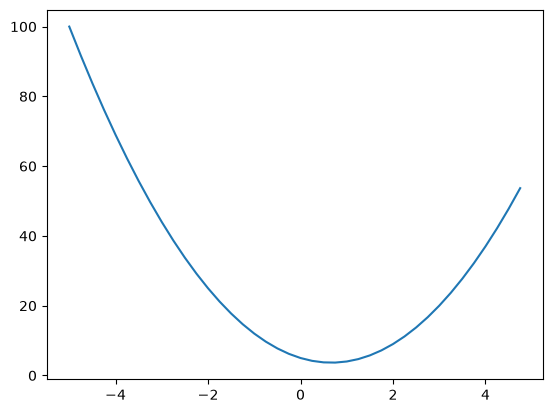

In [4]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs,ys)

In [5]:
h = 0.000001
x = 2/3
(f(x+h) - f(x)) / h

2.999378523327323e-06

In [6]:
# les get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0
d = a*b + c


d1 = a*b + c
c += h
d2 = a*b + c

print("d1", d1)
print("d2", d2)

print("slope", (d2-d1)/h)


d1 4.0
d2 4.0001
slope 0.9999999999976694


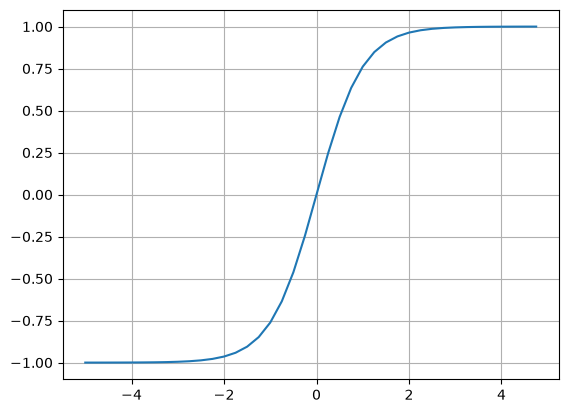

In [8]:
plt.plot(np.arange(-5, 5, 0.25), np.tanh(np.arange(-5, 5, 0.25))) 
plt.grid()

## Part 1 — The `Value` object

The core idea: wrap a single scalar, remember which values + operation produced it,
and give each one a `.grad`. `__init__` and `__repr__` are plumbing (given). The ops
and `backward()` are yours to fill in as the video builds them.


In [9]:
import math

class Value:
    """A scalar value node in the autograd graph."""

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        # --- autograd bookkeeping (used by backward() and draw_dot) ---
        self._backward = lambda: None     # closure: how to push grad to children
        self._prev = set(_children)       # the Values that produced this one
        self._op = _op                    # the op that produced this one (for the graph)
        self.label = label                # the label for the node (for the graph)
    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad}), prev={len(self._prev)}, op={self._op}"

    # ---- operations: build these up as Karpathy does in the video ----

    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out =  Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out

    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self,), f'**{other}')
        def _backward():
            self.grad += out.grad * other * self.data ** (other - 1)
        out._backward = _backward
        return out

    def tanh(self):
        #return Value(math.tanh(self.data), (self,), 'tanh')
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += out.grad * (1 - t ** 2)
        out._backward = _backward
        return out

    def exp(self):
        out = Value(math.exp(self.data), (self,), 'exp')
        def _backward():
            self.grad += out.grad * math.exp(self.data)
        out._backward = _backward
        return out

    def backward(self):
        # TODO: 1) build topological order of the graph
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        # TODO: 2) self.grad = 1.0
        self.grad = 1.0

        # 3) walk in reverse, calling node._backward()
        for node in reversed(topo):
            node._backward()

    # ---- convenience / reverse dunders (fill in near the end of the video) ----
    def __neg__(self):             
        # -self
        return self * -1
    def __radd__(self, other):    
        # other + self
        return self + other
    def __sub__(self, other):     
        # self - other
        return self + (-other)
    def __rsub__(self, other):    raise NotImplementedError   # other - self
    def __rmul__(self, other):       
        # other * self
        return self * other
    def __truediv__(self, other):   
        # self / other
        return self * (other ** -1)
    def __rtruediv__(self, other):raise NotImplementedError   # other / self


In [10]:
a = Value(3.0, label='a')
b = Value(2.0, label='b')
a - b


Value(data=1.0, grad=0.0), prev=2, op=+

Sanity check — this should work once `__add__` and `__mul__` are done:

In [11]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
a+b
c = Value(10.0, label='c')
d = a * b + c; d.label = 'd'

print(d)          # expect Value(data=4.0, grad=0.0)
# d.backward()
# print(a.grad, b.grad)   # expect -3.0, 2.0

Value(data=4.0, grad=0.0), prev=2, op=+


In [12]:
# input values
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights of the neuron
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias of the neuron
b = Value(6.7, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#x1w1x2w2b = x1w1x2w2 + b; x1w1x2w2b.label = 'x1*w1 + x2*w2 + b'


In [13]:
import torch

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [14]:
o

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)

## Visualization — `draw_dot` (given plumbing)

This is the graph drawer from `trace_graph.ipynb` — infrastructure, not the exercise.
Run it once your `Value` ops work and you'll *see* the computation graph + gradients.
Requires the graphviz binary (already installed in this env).


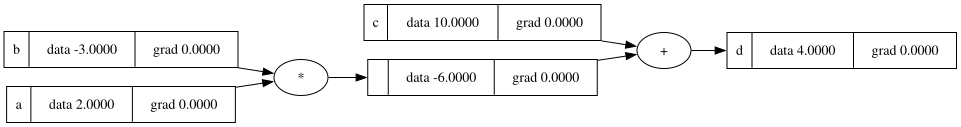

In [15]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """rankdir: 'LR' (left->right) or 'TB' (top->bottom)."""
    assert rankdir in ('LR', 'TB')
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir})
    for n in nodes:
        dot.node(name=str(id(n)),
                 label=f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}",
                 shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

draw_dot(d)   # <- uncomment after the sanity check above passes


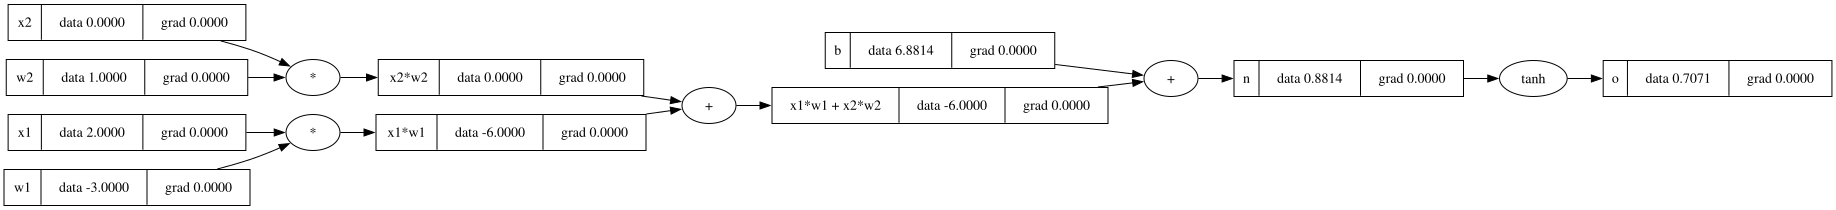

In [16]:
# input values
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights of the neuron
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'
draw_dot(o) 

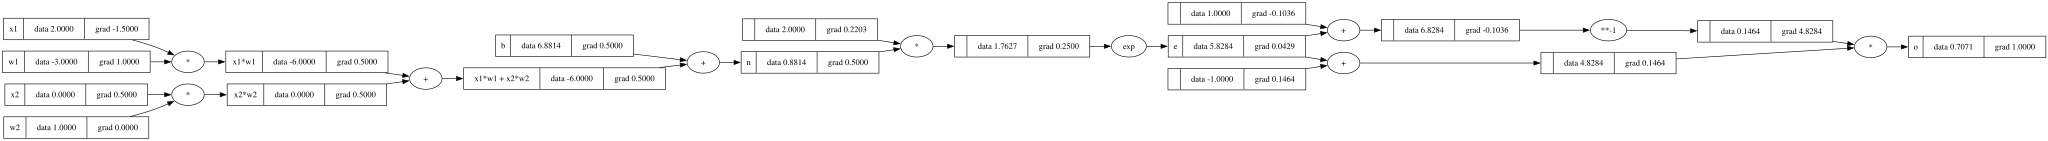

In [17]:
# input values
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights of the neuron
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
#bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

#----
e = (2 * n).exp(); 
e.label = 'e'
o= (e - 1) / (e + 1)
# ---
o.label = 'o'
o.backward()
draw_dot(o) 

In [18]:
o.backward()

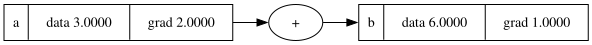

In [19]:
a = Value(3.0, label='a')
b = a + a
b.label = 'b'
b.backward()
draw_dot(b)   # <- uncomment after the sanity check above passes

In [20]:
a = Value(3.0, label='a')

3 + a

Value(data=6.0, grad=0.0), prev=2, op=+

## Part 2 — a tiny neural net: `Neuron`, `Layer`, `MLP`

Second half of the video. Each is built on top of `Value`, so backprop comes for free.


In [36]:
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi*xi) for wi, xi in zip(self.w, x)) + self.b
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]
    
    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [47]:
x=[2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.11039837213712461, grad=0.0), prev=1, op=tanh

In [48]:
#draw_dot(n(x))

In [49]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets




ypred = [n(x) for x in xs]
ypred

[Value(data=0.11039837213712461, grad=0.0), prev=1, op=tanh,
 Value(data=0.030624723564899495, grad=0.0), prev=1, op=tanh,
 Value(data=0.1871117818871186, grad=0.0), prev=1, op=tanh,
 Value(data=0.17807805591247247, grad=0.0), prev=1, op=tanh]

In [50]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=3.938368441987334, grad=0.0), prev=2, op=+

In [51]:
loss.backward()

In [52]:
len(n.parameters())

41

In [53]:
n.layers[0].neurons[0].w[0].data

-0.5971296494660372

In [31]:
#draw_dot(loss)

## Part 3 — training loop

The gradient-descent loop. Structure below as pseudocode — turn it into real code.
Watch the loss go down. **Gotcha from the video:** zero the grads each step before
`backward()`, or gradients accumulate and training misbehaves.


In [30]:
# toy dataset from the video
# xs = [[2.0, 3.0, -1.0],
#       [3.0, -1.0, 0.5],
#       [0.5, 1.0, 1.0],
#       [1.0, 1.0, -1.0]]
# ys = [1.0, -1.0, -1.0, 1.0]   # targets

# n = MLP(3, [4, 4, 1])

# for k in range(50):
#     # forward
#     ypred = [n(x) for x in xs]
#     loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
#
#     # backward  (ZERO GRADS FIRST!)
#     for p in n.parameters():
#         p.grad = 0.0
#     loss.backward()
#
#     # update (gradient descent)
#     for p in n.parameters():
#         p.data += -0.05 * p.grad
#
#     print(k, loss.data)


In [54]:
for p in n.parameters():
    p.data += -0.01*p.grad

In [59]:

n.layers[0].neurons[0].w[0].data

2.793593585448096

In [60]:
x=[2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.36447873826334226, grad=0.0), prev=1, op=tanh

In [63]:
for k in range(20):

    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout-ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.05 * p.grad


    print(k, loss.data)
     

0 0.0943001060418984
1 0.08653827309281378
2 0.07983535266789987
3 0.07399789691184223
4 0.06887560500454194
5 0.06435016297424626
6 0.06032732397325758
7 0.056731196004092585
8 0.05350005987268832
9 0.05058326513210019
10 0.04793889681409822
11 0.04553200093040399
12 0.04333322024590994
13 0.04131773488136866
14 0.03946443191340671
15 0.03775524878184291
16 0.036174649888175245
17 0.034709206181654406
18 0.033347255052160955
19 0.032078623341335655


In [64]:
ypred

[Value(data=0.9085887053324674, grad=-0.18282258933506523), prev=1, op=tanh,
 Value(data=-0.9757157055106421, grad=0.04856858897871574), prev=1, op=tanh,
 Value(data=-0.8692529442511979, grad=0.26149411149760415), prev=1, op=tanh,
 Value(data=0.9222949229283249, grad=-0.15541015414335013), prev=1, op=tanh]